# Módulo 5 · AR(1) a AR(p) sobre precios: LLR test y residuos

Curso: **Series Temporales con R y Python** (Frogames Formación).

Notebook de acompañamiento de la lección `05-modelos-ar/02-ar-precios-llr-test-y-residuos` — ábrelo mientras lees la lección y ejecuta cada celda tú mismo.

Trabajamos con `Index2018.csv` (en esta misma carpeta): precios de cierre diarios de cuatro índices bursátiles (S&P 500, DAX, FTSE 100, Nikkei 225), 1994-2018. Usamos la columna `ftse`.

**Nota de migración** (ver `AUDITORIA-TECNICA.md`): el notebook original usaba `statsmodels.tsa.arima_model.ARMA`, un módulo **eliminado** de `statsmodels`. El reemplazo es `statsmodels.tsa.arima.model.ARIMA` con `order=(p, 0, q)` — un ARMA(p,q) es un ARIMA(p,0,q) con `d=0`. El resultado se etiqueta "SARIMAX Results" (usa el framework de espacio de estados por debajo) pero `.summary()`, `.llf`, `.aic` y `.resid` son compatibles con el código original.

In [1]:
import matplotlib.pyplot as plt

# Estilo oscuro opcional, para que los gráficos combinen con el tema del curso.
# No afecta a ningún resultado numérico -- puedes omitir esta celda sin problema.
plt.rcParams.update({
    "figure.facecolor": "#0d0d10", "axes.facecolor": "#0d0d10",
    "axes.edgecolor": "#a8a8b3", "axes.labelcolor": "#e1e1e6",
    "xtick.color": "#a8a8b3", "ytick.color": "#a8a8b3",
    "text.color": "#e1e1e6", "grid.color": "#232326",
    "font.size": 11,
})

## Carga y preprocesado

In [2]:
import pandas as pd
import numpy as np
import statsmodels.graphics.tsaplots as sgt
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats.distributions import chi2
import statsmodels.tsa.stattools as sts

raw_csv_data = pd.read_csv("Index2018.csv")
df_comp = raw_csv_data.copy()
df_comp.date = pd.to_datetime(df_comp.date, dayfirst=True)
df_comp.set_index("date", inplace=True)
df_comp = df_comp.asfreq("B")
df_comp = df_comp.ffill()
df_comp.head()

,spx,dax,ftse,nikkei
date,,,,
1994-01-07,469.90,2224.95,3445.98,18124.01
1994-01-10,475.27,2225.00,3440.58,18443.44
1994-01-11,474.13,2228.10,3413.77,18485.25
1994-01-12,474.17,2182.06,3372.02,18793.88
1994-01-13,472.47,2142.37,3360.01,18577.26


In [3]:
df_comp["market_value"] = df_comp.ftse
del df_comp["spx"], df_comp["dax"], df_comp["ftse"], df_comp["nikkei"]

size = int(len(df_comp) * 0.8)
df, df_test = df_comp.iloc[:size], df_comp.iloc[size:]
print(f"train: {len(df)} filas · test: {len(df_test)} filas")

train: 5021 filas · test: 1256 filas


## ACF y PACF de los precios

La PACF de un AR(p) puro se corta bruscamente después del lag p — es la firma visual que ayuda a proponer un orden inicial antes de comparar modelos formalmente.

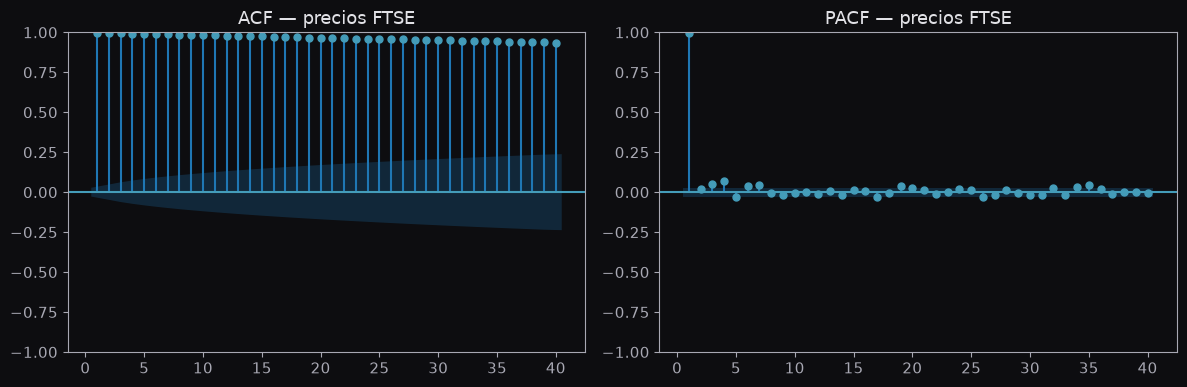

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sgt.plot_acf(df.market_value, zero=False, lags=40, ax=axes[0], color="#449cb9")
axes[0].set_title("ACF — precios FTSE")
sgt.plot_pacf(df.market_value, lags=40, alpha=0.05, zero=False, method="ols", ax=axes[1], color="#449cb9")
axes[1].set_title("PACF — precios FTSE")
plt.tight_layout()
plt.show()

## El modelo AR(1)

In [5]:
model_ar = ARIMA(df.market_value, order=(1, 0, 0))
results_ar = model_ar.fit()
print(results_ar.summary())

                               SARIMAX Results                                
Dep. Variable:           market_value   No. Observations:                 5021
Model:                 ARIMA(1, 0, 0)   Log Likelihood              -27622.604
Date:                Thu, 17 Sep 2026   AIC                          55251.207
Time:                        09:18:49   BIC                          55270.772
Sample:                    01-07-1994   HQIC                         55258.063
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5089.6374    423.328     12.023      0.000    4259.930    5919.345
ar.L1          0.9984      0.001   1147.579      0.000       0.997       1.000
sigma2      3511.3843     40.874     85.907      0.0

## AR(2), AR(3), AR(4)

In [6]:
model_ar_2 = ARIMA(df.market_value, order=(2, 0, 0))
results_ar_2 = model_ar_2.fit()
model_ar_3 = ARIMA(df.market_value, order=(3, 0, 0))
results_ar_3 = model_ar_3.fit()
model_ar_4 = ARIMA(df.market_value, order=(4, 0, 0))
results_ar_4 = model_ar_4.fit()

for name, res in [("AR(2)", results_ar_2), ("AR(3)", results_ar_3), ("AR(4)", results_ar_4)]:
    print(f"{name}: llf={res.llf:.3f}  aic={res.aic:.3f}")

AR(2): llf=-27621.949  aic=55251.898
AR(3): llf=-27615.962  aic=55241.925
AR(4): llf=-27602.680  aic=55217.359


## El test LLR (Log-Likelihood Ratio)

Compara dos modelos anidados: $LR = 2(L_2 - L_1)$, con $LR \sim \chi^2_{DF}$. Un p-valor pequeño dice que el modelo más grande explica significativamente más que el pequeño — no basta con que el log-likelihood suba, tiene que subir *lo suficiente*.

In [7]:
def LLR_test(mod_1, mod_2, DF=1):
    L1 = mod_1.llf
    L2 = mod_2.llf
    LR = 2 * (L2 - L1)
    p = chi2.sf(LR, DF).round(3)
    return p

print("LLR AR(2) vs AR(3):", LLR_test(results_ar_2, results_ar_3))
print("LLR AR(3) vs AR(4):", LLR_test(results_ar_3, results_ar_4))

LLR AR(2) vs AR(3): 0.001
LLR AR(3) vs AR(4): 0.0


## Escalera AR(5) a AR(8)

Seguimos subiendo el orden mientras el LLR test siga siendo significativo frente al modelo anterior.

In [8]:
results = {1: results_ar, 2: results_ar_2, 3: results_ar_3, 4: results_ar_4}
prev = results_ar_4
for p in range(5, 9):
    model = ARIMA(df.market_value, order=(p, 0, 0))
    res = model.fit()
    results[p] = res
    pval = LLR_test(prev, res)
    print(f"AR({p}): llf={res.llf:.3f}  aic={res.aic:.3f}  LLR vs AR({p-1})={pval}")
    prev = res

AR(5): llf=-27600.460  aic=55214.920  LLR vs AR(4)=0.035


AR(6): llf=-27596.587  aic=55209.174  LLR vs AR(5)=0.005


AR(7): llf=-27592.022  aic=55202.044  LLR vs AR(6)=0.003


AR(8): llf=-27591.854  aic=55203.708  LLR vs AR(7)=0.562


In [9]:
print("LLR test AR(1) vs AR(7), DF=6:", LLR_test(results[1], results[7], DF=6))

LLR test AR(1) vs AR(7), DF=6: 0.0


AR(8) no mejora significativamente a AR(7) (LLR p-valor > 0.05) — nos quedamos con **AR(7)** como mejor modelo de esta escalera.

## Analizando los residuos del modelo AR(7)

Si el modelo capturó bien la estructura autorregresiva, los residuos deberían comportarse como ruido blanco: estacionarios y sin autocorrelación significativa.

In [10]:
best = results[7]
df["res_price"] = best.resid
df[["res_price"]].describe()

,res_price
count,5021.000000
mean,0.351971
std,63.291564
min,-1643.660864
25%,-26.832224
50%,2.176383
75%,29.724752
max,418.410375


In [11]:
adf_result = sts.adfuller(df.res_price)
print(f"estadístico ADF = {adf_result[0]:.6f}")
print(f"p-valor         = {adf_result[1]:.6f}")
print(f"valores críticos = {adf_result[4]}")

estadístico ADF = -76.053394
p-valor         = 0.000000
valores críticos = {'1%': np.float64(-3.431653316130827), '5%': np.float64(-2.8621159253018247), '10%': np.float64(-2.5670765656497516)}


/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_6283/67272137.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.res_price)


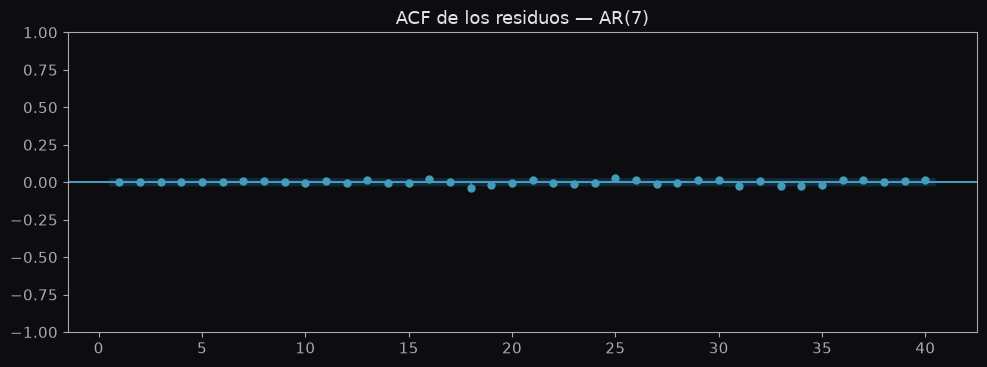

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.8))
sgt.plot_acf(df.res_price, zero=False, lags=40, ax=ax, color="#449cb9")
ax.set_title("ACF de los residuos — AR(7)")
plt.tight_layout()
plt.show()

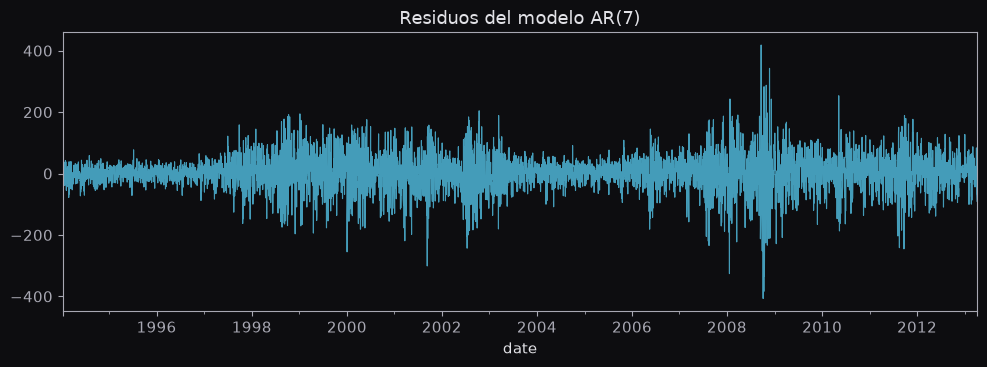

In [13]:
fig, ax = plt.subplots(figsize=(10, 3.8))
df.res_price.iloc[1:].plot(ax=ax, color="#449cb9", linewidth=0.8)
ax.set_title("Residuos del modelo AR(7)")
plt.tight_layout()
plt.show()

**Entregable**: reproduce estas celdas y, en tus notas, contesta: el ADF test sobre los residuos da un p-valor prácticamente cero. ¿Qué hipótesis nula rechaza exactamente ese test, y por qué es una buena noticia para el modelo AR(7) que se rechace?

## AR sobre retornos: el mismo flujo, un activo muy distinto

Todo lo anterior fue sobre precios. El retorno -- la variacion porcentual dia a dia -- es una transformacion completamente distinta, y es lo que se modela de verdad en los modulos de MA, ARMA y ARIMA que vienen despues. Repetimos aqui el mismo flujo completo (ACF/PACF, escalera con LLR test, residuos) pero sobre los retornos del mismo FTSE.

In [14]:
df["returns"] = df.market_value.pct_change(1) * 100
df.head()

,market_value,res_price,returns
date,,,
1994-01-07,3445.98,-1643.660864,NaN
1994-01-10,3440.58,-8.530196,-0.156704
1994-01-11,3413.77,-29.989056,-0.779229
1994-01-12,3372.02,-45.480241,-1.222988
1994-01-13,3360.01,-17.493059,-0.356166


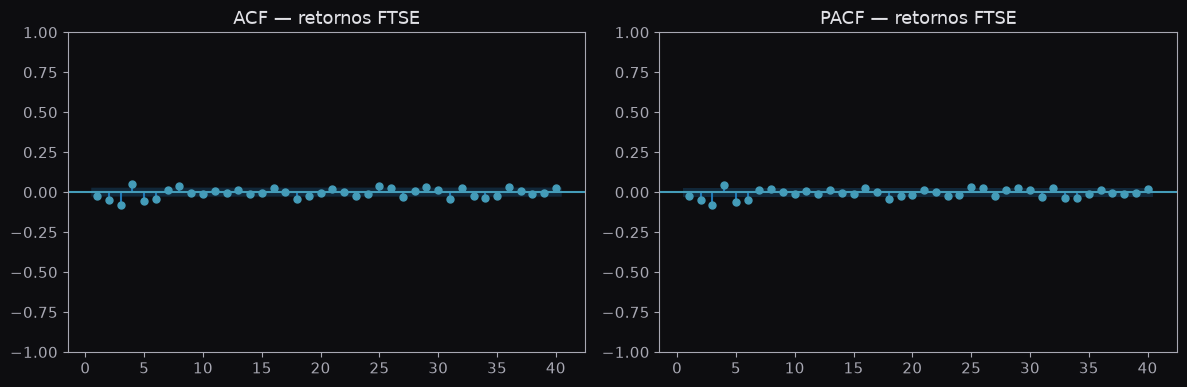

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sgt.plot_acf(df.returns[1:], zero=False, lags=40, ax=axes[0], color="#449cb9")
axes[0].set_title("ACF — retornos FTSE")
sgt.plot_pacf(df.returns[1:], lags=40, alpha=0.05, zero=False, method="ols", ax=axes[1], color="#449cb9")
axes[1].set_title("PACF — retornos FTSE")
plt.tight_layout()
plt.show()

Compara esta ACF/PACF con la de precios: alli la ACF apenas decaia (no estacionariedad); aqui las barras estan practicamente pegadas a cero desde el primer lag -- la firma visual de una serie mucho mas cercana al ruido blanco.

In [16]:
model_ar_ret_1 = ARIMA(df.returns[1:], order=(1, 0, 0))
results_ar_ret_1 = model_ar_ret_1.fit()
print(results_ar_ret_1.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 5020
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -7929.749
Date:                Thu, 17 Sep 2026   AIC                          15865.497
Time:                        09:18:50   BIC                          15885.061
Sample:                    01-10-1994   HQIC                         15872.353
                         - 04-05-2013                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0188      0.016      1.143      0.253      -0.013       0.051
ar.L1         -0.0230      0.009     -2.697      0.007      -0.040      -0.006
sigma2         1.3790      0.014    100.092      0.0

El contraste que importa: `ar.L1=0.9984` sobre precios (practicamente 1, caminata aleatoria) frente a `ar.L1=-0.0230` sobre retornos (cerca de 0, con signo negativo). Un coeficiente autorregresivo cercano a 1 no aporta nada util para pronosticar; uno pequeño y significativo si es señal aprovechable -- por eso el resto del curso modela retornos, no precios.

### Escalera con LLR test sobre retornos

In [17]:
results_ret = {1: results_ar_ret_1}
model_ar_ret_2 = ARIMA(df.returns[1:], order=(2, 0, 0))
results_ret[2] = model_ar_ret_2.fit()
print("LLR AR(1) vs AR(2) retornos:", LLR_test(results_ret[1], results_ret[2]))

prev = results_ret[2]
for p in range(3, 8):
    model = ARIMA(df.returns[1:], order=(p, 0, 0))
    res = model.fit()
    results_ret[p] = res
    pval = LLR_test(prev, res)
    print(f"AR({p}) retornos: llf={res.llf:.3f}  aic={res.aic:.3f}  LLR vs AR({p-1})={pval}")
    prev = res

LLR AR(1) vs AR(2) retornos: 0.0


AR(3) retornos: llf=-7906.738  aic=15823.477  LLR vs AR(2)=0.0


AR(4) retornos: llf=-7901.330  aic=15814.661  LLR vs AR(3)=0.001


AR(5) retornos: llf=-7892.390  aic=15798.779  LLR vs AR(4)=0.0


AR(6) retornos: llf=-7886.945  aic=15789.890  LLR vs AR(5)=0.001


AR(7) retornos: llf=-7886.647  aic=15791.294  LLR vs AR(6)=0.44


El LLR test de AR(7) frente a AR(6) da un p-valor de 0.44 -- no significativo. El AIC confirma la misma conclusion: AR(6) tiene el AIC mas bajo de toda la escalera. Nos quedamos con **AR(6)** como mejor modelo sobre retornos -- un lag menos que el AR(7) que gano sobre precios.

## Residuos del AR(6) sobre retornos

In [18]:
best_ret = results_ret[6]
df["res_ret"] = np.nan
df.loc[df.index[1:], "res_ret"] = best_ret.resid

adf_result = sts.adfuller(df.res_ret.dropna())
print(f"estadístico ADF = {adf_result[0]:.6f}")
print(f"p-valor         = {adf_result[1]:.6f}")
print(f"valores críticos = {adf_result[4]}")

estadístico ADF = -70.784118
p-valor         = 0.000000
valores críticos = {'1%': np.float64(-3.4316535759402753), '5%': np.float64(-2.8621160400844468), '10%': np.float64(-2.567076626752987)}


/var/folders/1k/2gl0gzxd1t12r58tgchyn4dc0000gn/T/ipykernel_6283/1249090853.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = sts.adfuller(df.res_ret.dropna())


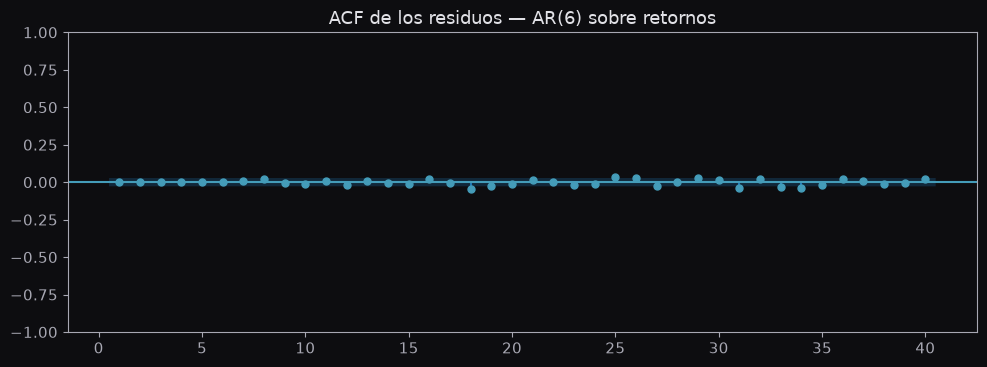

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.8))
sgt.plot_acf(df.res_ret.dropna(), zero=False, lags=40, ax=ax, color="#449cb9")
ax.set_title("ACF de los residuos — AR(6) sobre retornos")
plt.tight_layout()
plt.show()

**Entregable**: reproduce estas celdas. Repite la escalera (precios y retornos) con la columna `spx` en vez de `ftse`. Compara `ar.L1` del AR(1) sobre precios con el del AR(1) sobre retornos y explica por escrito por que un coeficiente cercano a 1 es un problema para pronosticar y uno cercano a 0 (pero significativo) no lo es.